In [4]:
# ! pip install torch torchvision torchaudio  # this might take a few minutes
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
# print("CUDA Available:", torch.cuda.is_available())

In [15]:
# Split the dataset into train and test sets 
# Remember that we want to evaluate performance on a test set to avoid overfitting 
test_data = datasets.MNIST(
    root=".",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

test_loader = torch.utils.data.DataLoader(
    test_data,
    batch_size=16,
    shuffle=True
)

In [16]:
# Define the model architecture
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 28*28)   # flatten image
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x
    
model = SimpleNN()

In [17]:
# Define a loss function 

# We use a different loss function here from MSE...
# Cross Entropy Loss is commonly used for classification tasks
loss_fn = nn.CrossEntropyLoss()

In [18]:
# Define an optimization scheme 

# SGD == stoichastic gradient descent
# Remember we want to explore stoichastically to avoid getting trapped in a local minimum
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [19]:
n_epochs = 10
for epoch in range(n_epochs):
    for x, y in train_loader:

        # forward pass
        pred = model(x)
        loss = loss_fn(pred, y)

        # backward pass (computes gradients automatically)
        optimizer.zero_grad()
        loss.backward()

        # update weights
        optimizer.step()

    print("epoch:", epoch, "loss:", loss.item())

epoch: 0 loss: 0.6594754457473755
epoch: 1 loss: 0.4999009668827057
epoch: 2 loss: 0.2641145884990692
epoch: 3 loss: 0.4831702709197998
epoch: 4 loss: 0.4190049171447754
epoch: 5 loss: 0.1979658603668213
epoch: 6 loss: 0.561966598033905
epoch: 7 loss: 0.3681098520755768
epoch: 8 loss: 0.11132623255252838
epoch: 9 loss: 0.19129453599452972


In [20]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

def show_predictions(model, loader, title="Model"):
    model.eval()

    x, y = next(iter(loader))
    
    with torch.no_grad():
        logits = model(x)
        probs = F.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    fig.suptitle(title)

    for i, ax in enumerate(axes.flat):
        ax.imshow(x[i].squeeze(), cmap="gray")
        
        pred = preds[i].item()
        true = y[i].item()
        conf = probs[i][pred].item()

        color = "green" if pred == true else "red"
        ax.set_title(f"P:{pred} ({conf:.2f})\nT:{true}", color=color)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

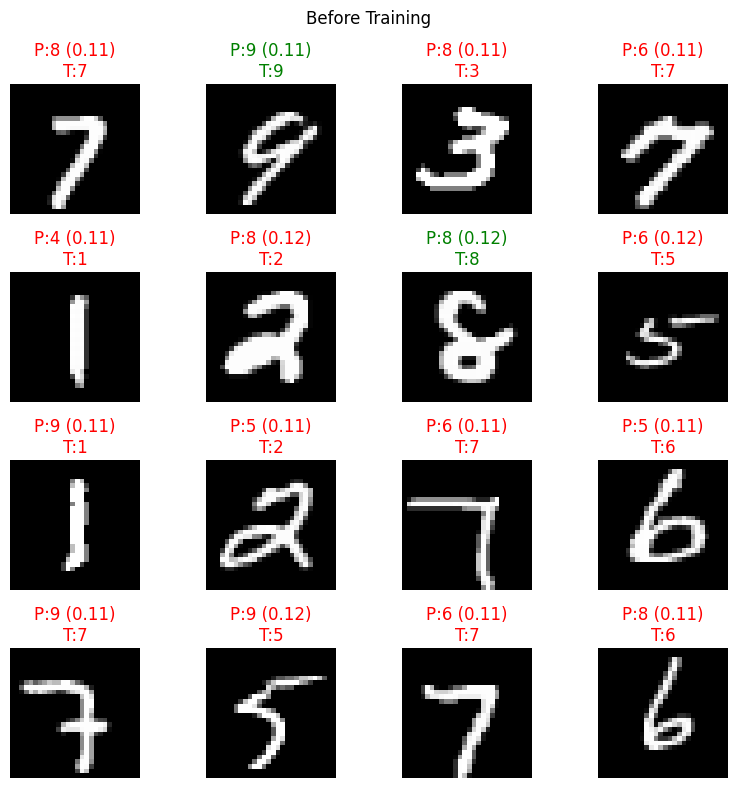

In [21]:
model_untrained = SimpleNN()
show_predictions(model_untrained, test_loader, title="Before Training")

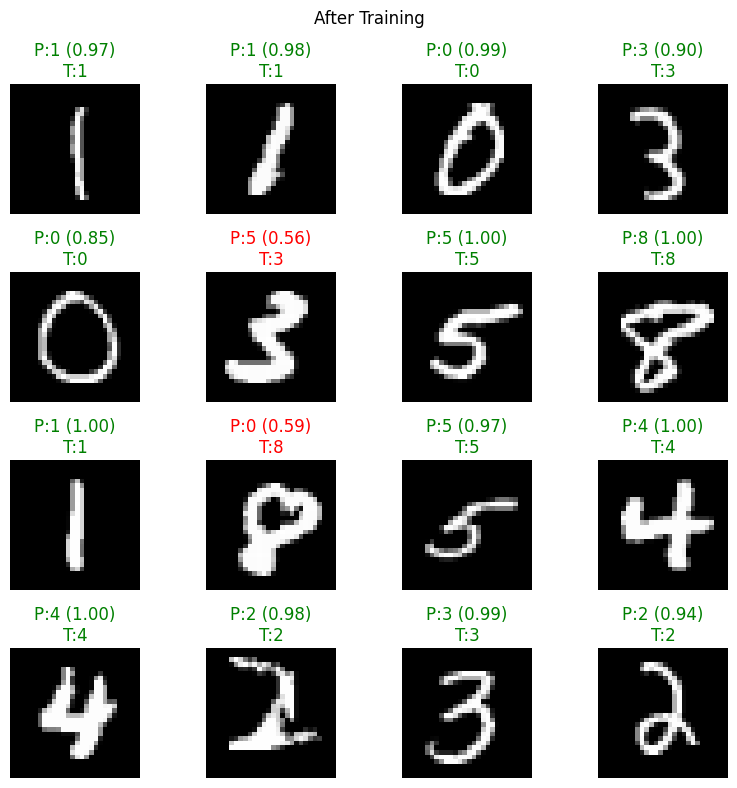

In [23]:
show_predictions(model, test_loader, title="After Training")